# Temporal ARSS — Wikipedia (JODIE) Dataset
**Honours Project Phase II | IIIT Kottayam**

---

## What this notebook does

This notebook implements **Temporal ARSS** — a direct extension of Base ARSS that
incorporates **time-decay into the reweighted similarity `w_ik`**.

### The single change vs Base ARSS

Base ARSS ranks neighbors by structural similarity alone:
```
w_ik = 2 * π_ik / (1 + η_ik)          ← Eq. 2-4, pure topology
```
Lower `w_ik` = more structurally similar = sampled first.

Temporal ARSS multiplies by an exponential recency penalty:
```
w_ik_temporal = w_ik_base * exp(+λ * Δt / T_SCALE)    ← Phase II extension
```
where `Δt = t_query - t_last_interaction(i, k)` and `λ > 0` is a fixed decay rate swept as a hyperparameter.

**Effect:** A neighbor that is structurally close but interacted long ago gets a
higher `w_ik_temporal` (lower priority) than a slightly less similar neighbor
who interacted recently. Recency breaks structural ties.

**Why multiplicative (not additive)?**
The `exp(+λ * Δt / T_SCALE)` factor operates on the *precomputed static* `w_ik` values
which already have meaningful spread. The penalty stretches that spread further —
recent interactions retain their structural priority, old ones get pushed down the ranking.

### What is identical to Base ARSS
- Same `w_ik` formula (Eq. 2-4) on the static training graph
- Same breadth-then-depth sampling (Eq. 5) — just using `w_ik_temporal` instead of `w_ik`
- Same anonymous subgraph builder (5 structural roles)
- Same `SubgraphGNN` (GraphSAGE)
- Same `LinkPredictor` (Hadamard + common neighbor sum → MLP)
- Same training loop, evaluation, splits
- **No new model parameters** — λ is a hyperparameter, not a learned weight

### Pipeline overview
```
Wikipedia JODIE (157K timestamped user→page edits)
         │
         ▼
Chronological 70/15/15 split
         │
         ▼
Build STATIC graph from train edges (same as Base ARSS)
Precompute w_ik for all train edges (Eq. 2-4)
Build last-interaction time lookup: t_last[i][k]
         │
         ▼
For each batch of (u, v) edges at time t_query:
   For each neighbor k of u (or v):
       Δt = t_query - t_last[u][k]
       w_ik_temporal = w_ik_base * exp(+λ * Δt / T_SCALE)
   Sort by w_ik_temporal ascending → take top-K  (breadth-then-depth)
   Build anonymous subgraph → GraphSAGE → MLP → link probability
         │
         ▼
Sweep λ ∈ {1.0, 10.0} — evaluate AUC / AP — compare against Base ARSS baseline
```


---
## Cell 1 — Imports and Device Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import copy

from torch_geometric.datasets import JODIEDataset
from torch_geometric.data import TemporalData, Data, Batch
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


---
## Cell 2 — Load and Split the Wikipedia JODIE Dataset

Identical to Base ARSS. Same splits, same normalization, same dst offset.
We additionally build two temporal structures that Base ARSS doesn't need:
- **`t_last[i][k]`** — the most recent timestamp of interaction between nodes i and k in the training set
- **`T_SCALE`** — normalisation constant for Δt (full training time span, so Δt/T_SCALE ∈ [0, 1])


In [2]:
from torch_geometric.datasets import JODIEDataset
from torch_geometric.data import TemporalData
import math
from collections import defaultdict

# ── Load JODIE Wikipedia ──────────────────────────────────────────────────────
dataset = JODIEDataset(root='./data', name='Wikipedia')
data    = dataset[0]

EDGE_FEAT_DIM = data.msg.shape[1]   # 172 for Wikipedia
print(f'Edges      : {data.num_events:,}')
print(f'Feat dim   : {EDGE_FEAT_DIM}')
print(f'Time range : [{data.t.min().item():.0f}, {data.t.max().item():.0f}]')

# ── Chronological 70/15/15 split ─────────────────────────────────────────────
n      = data.num_events
val_t  = data.t[int(n * 0.70)].item()
test_t = data.t[int(n * 0.85)].item()

def split(data, mask):
    return TemporalData(
        src=data.src[mask], dst=data.dst[mask],
        t=data.t[mask],     msg=data.msg[mask],
    )

train_data = split(data, data.t <  val_t)
val_data   = split(data, (data.t >= val_t) & (data.t < test_t))
test_data  = split(data, data.t >= test_t)

# ── Normalize edge features (fit on train only) ───────────────────────────────
mean = train_data.msg.mean(0, keepdim=True)
std  = train_data.msg.std(0,  keepdim=True).clamp(min=1e-6)
for d in [train_data, val_data, test_data]:
    d.msg = (d.msg - mean) / std

# ── Node counts + dst offset ──────────────────────────────────────────────────
N_USERS = int(data.src.max()) + 1
N_ITEMS = int(data.dst.max()) + 1
print(f'\nID ranges  : src 0-{data.src.max().item()},  dst 0-{data.dst.max().item()}')

for d in [train_data, val_data, test_data, data]:
    d.dst = d.dst + N_USERS

NUM_NODES = N_USERS + N_ITEMS

# ── Flat numpy arrays for the sampler (same as Base ARSS) ────────────────────
train_src = train_data.src.numpy()
train_dst = train_data.dst.numpy()
train_t   = train_data.t.numpy()
val_src   = val_data.src.numpy()
val_dst   = val_data.dst.numpy()
val_t_arr = val_data.t.numpy()
test_src  = test_data.src.numpy()
test_dst  = test_data.dst.numpy()
test_t_arr= test_data.t.numpy()

# ── T_SCALE: median inter-event gap ──────────────────────────────────────────
# Maps Δt values into a numerically stable range for exp(-λ * Δt / T_SCALE).
# Using median gap means exp(-λ * 1) is the decay for a "typical" gap — λ has
# an interpretable meaning: λ=1 means half-life ≈ 1 median gap.
# T_SCALE = full training time span.
# Ensures Δt/T_SCALE ∈ [0,~1] for train, [0,~1.3] for val/test.
# Median gap caused val/test Δt >> T_SCALE → all decays → 0 → no temporal signal.
T_MIN       = float(train_data.t.min())
T_MAX_TRAIN = float(train_data.t.max())
T_SCALE     = max(T_MAX_TRAIN - T_MIN, 1.0)

print(f'Nodes      : {NUM_NODES:,}  ({N_USERS} users + {N_ITEMS} pages)')
print(f'Train      : {len(train_src):,}')
print(f'Val        : {len(val_src):,}')
print(f'Test       : {len(test_src):,}')
print(f'T_SCALE    : {T_SCALE:.1f}s  (median inter-event gap)')

# ── Build static adjacency + w_ik (identical to Base ARSS) ───────────────────
import time as _time
adj    = defaultdict(set)
for u, v in zip(train_src.tolist(), train_dst.tolist()):
    adj[u].add(v)
    adj[v].add(u)

degree   = {node: len(nb) for node, nb in adj.items()}
d_max    = max(degree.values()) if degree else 1

def psi(x):
    return math.log(1.0 + x)

psi_dmax = psi(d_max)

def compute_w_ik(i, k):
    """Eq. 2-4 from paper. Lower = more structurally similar."""
    d_i = degree.get(i, 0)
    d_k = degree.get(k, 0)
    pi_ik  = (psi(d_i) + psi(d_k)) / (2.0 * psi_dmax)
    common = adj.get(i, set()) & adj.get(k, set())
    if common:
        prod   = math.prod(psi(degree.get(u, 1)) / psi_dmax for u in common)
        eta_ik = 1.0 - prod
    else:
        eta_ik = 0.0
    return (2.0 * pi_ik) / (1.0 + eta_ik)

print('\nPrecomputing w_ik for all 1-hop neighbour pairs...')
t0      = _time.time()
w_cache = {}
for node, neighbours in adj.items():
    for nb in neighbours:
        if (node, nb) not in w_cache:
            w = compute_w_ik(node, nb)
            w_cache[(node, nb)] = w
            w_cache[(nb, node)] = w
print(f'Done: {len(w_cache):,} pairs in {_time.time()-t0:.1f}s')

# ── Build t_last[i][k]: most recent training timestamp for each edge ──────────
# This is the key temporal structure Base ARSS doesn't have.
# For a query at time t, Δt = t - t_last[i][k].
print('Building t_last lookup...')
t_last = defaultdict(dict)   # t_last[node_i][node_k] = most recent t
for u, v, t in zip(train_src.tolist(), train_dst.tolist(), train_t.tolist()):
    # Update both directions
    t_last[u][v] = max(t_last[u].get(v, -1), t)
    t_last[v][u] = max(t_last[v].get(u, -1), t)
print(f'Done: {sum(len(v) for v in t_last.values()):,} node-pair timestamps')


Edges      : 157,474
Feat dim   : 172
Time range : [0, 2678373]

ID ranges  : src 0-8226,  dst 0-9226
Nodes      : 17,454  (8227 users + 9227 pages)
Train      : 110,231
Val        : 23,620
Test       : 23,623
T_SCALE    : 1862645.0s  (median inter-event gap)

Precomputing w_ik for all 1-hop neighbour pairs...
Done: 27,090 pairs in 0.2s
Building t_last lookup...
Done: 27,090 node-pair timestamps


---
## Cell 3 — Temporal Neighbor Sampler

The key function is `sample_subgraph_nodes_temporal`, a direct extension of
Base ARSS's `sample_subgraph_nodes`:

**Base ARSS:** rank neighbors by `w_ik` (static topology only)

**Temporal ARSS:** rank neighbors by `w_ik * exp(+λ * Δt / T_SCALE)`

where `Δt = t_query - t_last[i][k]`. The positive exponent means older edges
get a larger penalty (higher score), pushing them down the priority list.
If i and k have never interacted in training, penalty = ∞, so the neighbor
is deprioritised to the bottom of the ranking.

`λ` is a **fixed hyperparameter** swept over `[1.0, 10.0]` — it cannot be
learned via backprop because `sorted()` is outside PyTorch autograd.


In [3]:
def temporal_score(v_i, k, t_query, lam):
    """
    Temporal reweighting of w_ik (Equation 2-4 + time decay).
    w_ik_temporal = w_ik * exp(+λ * Δt / T_SCALE)
    Higher score = deprioritised (same ascending sort convention as base ARSS).
    Recent neighbors get smaller penalty → lower score → sampled first.
    Older neighbors get larger penalty  → higher score → sampled last.
    """
    w_base  = w_cache.get((v_i, k), compute_w_ik(v_i, k))
    t_last_ = t_last[v_i].get(k, None)
    if t_last_ is not None:
        dt      = max(t_query - t_last_, 0.0)
        penalty = math.exp(lam * dt / T_SCALE)   # +exponent: old = bigger score
    else:
        penalty = float('inf')                    # never interacted = lowest priority
    return w_base * penalty


def sample_subgraph_nodes_temporal(v_i, K, t_query, lam, max_hops=2):
    """
    Breadth-then-depth sampling (Equation 5) with temporal reweighting.
    Identical structure to base ARSS — only the scoring key changes.
    """
    selected     = []
    selected_set = set()
    visited      = {v_i}
    frontier     = adj.get(v_i, set()).copy()

    for _ in range(1, max_hops + 1):
        candidates = frontier - selected_set - {v_i}
        if not candidates:
            break

        remaining = K - len(selected)
        if remaining <= 0:
            break

        ranked = sorted(candidates,
                        key=lambda k: temporal_score(v_i, k, t_query, lam))

        if len(candidates) <= remaining:
            batch = ranked
        else:
            batch = ranked[:remaining]

        selected.extend(batch)
        selected_set.update(batch)
        visited.update(batch)

        if len(selected) >= K:
            break

        frontier = set()
        for nd in selected_set:
            frontier |= adj.get(nd, set())
        frontier -= visited

    return selected[:K]

---
## Cell 4 — The Temporal ARSS Model

**Identical to Base ARSS** in every component — same GNN, same link predictor,
same subgraph structure, same parameter count. No new parameters.

The only difference is outside the model: `build_batch_subgraphs_temporal`
calls `sample_subgraph_nodes_temporal` with the current `LAMBDA` and `t_query`,
so subgraph composition reflects recency at query time.


In [4]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data, Batch

NUM_ROLES = 5

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Anonymous Subgraph Builder (identical to Base ARSS)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def build_anonymous_subgraph(u, v, u_neighbors, v_neighbors):
    u_set  = set(u_neighbors)
    v_set  = set(v_neighbors)
    common = u_set & v_set
    all_nodes = [u, v] + list(u_set | v_set)
    n2l = {n: i for i, n in enumerate(all_nodes)}
    N   = len(all_nodes)

    roles    = torch.zeros(N, dtype=torch.long)
    roles[0] = 0; roles[1] = 1
    for nd in all_nodes[2:]:
        roles[n2l[nd]] = 2 if nd in common else (3 if nd in u_set else 4)

    x = F.one_hot(roles, num_classes=NUM_ROLES).float()

    esrc, edst = [], []
    for nb in u_neighbors:
        a, b = n2l[u], n2l[nb]; esrc += [a, b]; edst += [b, a]
    for nb in v_neighbors:
        a, b = n2l[v], n2l[nb]; esrc += [a, b]; edst += [b, a]

    if esrc:
        edge_index = torch.tensor([esrc, edst], dtype=torch.long)
    else:
        edge_index = torch.tensor([[0, 1], [1, 0]], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, common_mask=(roles == 2))


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  GNN Encoder (identical to Base ARSS)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class SubgraphGNN(nn.Module):
    def __init__(self, in_ch=NUM_ROLES, hidden=128, out=64, layers=2, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        dims = [in_ch] + [hidden] * (layers - 1) + [out]
        self.convs = nn.ModuleList([SAGEConv(dims[i], dims[i+1]) for i in range(layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(dims[i+1]) for i in range(layers)])

    def forward(self, x, edge_index):
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Link Predictor (identical to Base ARSS, Eq. 8-9)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class LinkPredictor(nn.Module):
    def __init__(self, emb_dim=64, hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 1)
        )

    def forward(self, h_i, h_j, h_common):
        hadamard = h_i * h_j                            # Eq. 8
        z_ij     = torch.cat([hadamard, h_common], dim=-1)
        return self.mlp(z_ij).squeeze(-1)               # Eq. 9


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Temporal ARSS Model
#  λ is a fixed hyperparameter — no new parameters vs Base ARSS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

class TemporalARSSModel(nn.Module):
    def __init__(self, hidden=128, emb_dim=64, dropout=0.3):
        super().__init__()
        self.emb_dim   = emb_dim
        self.gnn       = SubgraphGNN(NUM_ROLES, hidden, emb_dim, 2, dropout)
        self.predictor = LinkPredictor(emb_dim, hidden)
        # λ is a hyperparameter set outside the model — not a parameter here.

    def forward(self, subgraphs):
        """subgraphs: list of Data objects. Returns logits [B]."""
        B      = len(subgraphs)
        device = next(self.parameters()).device

        batch    = Batch.from_data_list(subgraphs).to(device)
        all_embs = self.gnn(batch.x, batch.edge_index)

        starts = batch.ptr[:-1]
        h_i    = all_embs[starts]
        h_j    = all_embs[starts + 1]

        h_common = torch.zeros(B, self.emb_dim, device=device)
        for idx, sg in enumerate(subgraphs):
            cm = sg.common_mask
            if cm.any():
                start         = batch.ptr[idx].item()
                sg_embs       = all_embs[start: start + sg.num_nodes]
                h_common[idx] = sg_embs[cm.to(device)].sum(dim=0)   # Eq. 8: sum

        return self.predictor(h_i, h_j, h_common)


model = TemporalARSSModel(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Parameters : {total:,}  (identical to Base ARSS)')
print(model)


Parameters : 43,073  (identical to Base ARSS)
TemporalARSSModel(
  (gnn): SubgraphGNN(
    (convs): ModuleList(
      (0): SAGEConv(5, 128, aggr=mean)
      (1): SAGEConv(128, 64, aggr=mean)
    )
    (norms): ModuleList(
      (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (predictor): LinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


---
## Cell 5 — Training Configuration

Same hyperparameters as Base ARSS (K=10, batch=512, epochs=15, LR=3e-4).

Key addition in `build_batch_subgraphs_temporal`: passes `t_query` and
the current fixed `λ` to the sampler so subgraph composition reflects recency
at query time. λ is swept externally over `[1.0, 10.0]` — each value trains
a fresh model from scratch and the best validation AUC determines the winner.

Because subgraph sampling is non-differentiable (`sorted()` is outside
PyTorch autograd), λ is not a learnable parameter and receives no gradient.
The GNN and MLP parameters are trained as usual with Adam + BCE loss.


In [5]:
import os, time
import numpy as np

K          = 10
BATCH_SIZE = 512
EPOCHS     = 15
LR         = 3e-4
VALIDATE_EVERY = 1
rng = np.random.default_rng(SEED)

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)


def get_batches_temporal(src_arr, dst_arr, t_arr, batch_size):
    n = len(src_arr)
    for s in range(0, n, batch_size):
        e = min(s + batch_size, n)
        yield src_arr[s:e], dst_arr[s:e], t_arr[s:e]


def negative_sample(src, n_items, offset):
    return rng.integers(offset, offset + n_items, size=len(src))


def bce_loss(pos_logits, neg_logits):
    logits = torch.cat([pos_logits, neg_logits])
    labels = torch.cat([torch.ones_like(pos_logits), torch.zeros_like(neg_logits)])
    return F.binary_cross_entropy_with_logits(logits, labels)


def build_batch_subgraphs_temporal(src_batch, dst_batch, t_batch, K, lam):
    """
    Build anonymous subgraphs using temporal reweighting.
    lam: current λ value (float, detached from graph for sampling).
    """
    subgraphs = []
    for u, v, t_q in zip(src_batch.tolist(), dst_batch.tolist(), t_batch.tolist()):
        u_nb = sample_subgraph_nodes_temporal(u, K, t_q, lam)
        v_nb = sample_subgraph_nodes_temporal(v, K, t_q, lam)
        subgraphs.append(build_anonymous_subgraph(u, v, u_nb, v_nb))
    return subgraphs


print(f'Config: K={K}, batch={BATCH_SIZE}, epochs={EPOCHS}, lr={LR}')
print(f'Batches per epoch: {len(train_src) // BATCH_SIZE + 1}')
print(f'T_SCALE: {T_SCALE:.1f}s')


Config: K=10, batch=512, epochs=15, lr=0.0003
Batches per epoch: 216
T_SCALE: 1862645.0s


---
## Cell 6 — Evaluation Function

Same as Base ARSS except we pass `t_arr` (timestamps) through the batch
so the temporal sampler knows `t_query` for each edge.
λ is passed as an argument — the same value used during training.


In [6]:
@torch.no_grad()
def evaluate(model, src_arr, dst_arr, t_arr, K, n_items, offset, lam):
    model.eval()
    all_scores, all_labels = [], []

    for src_b, dst_b, t_b in get_batches_temporal(src_arr, dst_arr, t_arr, BATCH_SIZE):
        neg_dst = negative_sample(src_b, n_items, offset)

        pos_sgs = build_batch_subgraphs_temporal(src_b, dst_b,  t_b, K, lam)
        neg_sgs = build_batch_subgraphs_temporal(src_b, neg_dst, t_b, K, lam)

        pos_logits = model(pos_sgs)
        neg_logits = model(neg_sgs)

        scores = torch.cat([pos_logits, neg_logits]).sigmoid().cpu().numpy()
        labels = np.array([1] * len(pos_logits) + [0] * len(neg_logits))
        all_scores.append(scores)
        all_labels.append(labels)

    from sklearn.metrics import roc_auc_score, average_precision_score
    all_scores = np.concatenate(all_scores)
    all_labels = np.concatenate(all_labels)
    return roc_auc_score(all_labels, all_scores), average_precision_score(all_labels, all_scores)


print('evaluate() ready ✓')


evaluate() ready ✓


In [9]:
import random
# ── Quick check: does max_hops=1 actually zero out the common-neighbor term? ──
def check_common_neighbors_fixed_hops(src_arr, dst_arr, t_arr, label, lam, max_hops, n_sample=3000):
    idx = random.sample(range(len(src_arr)), min(n_sample, len(src_arr)))
    sampled_common_counts = []
    for i in idx:
        u, v, t_q = int(src_arr[i]), int(dst_arr[i]), float(t_arr[i])
        u_nb = sample_subgraph_nodes_temporal(u, K, t_q, lam, max_hops=max_hops)
        v_nb = sample_subgraph_nodes_temporal(v, K, t_q, lam, max_hops=max_hops)
        sampled_common_counts.append(len(set(u_nb) & set(v_nb)))
    sampled_common_counts = np.array(sampled_common_counts)
    print(f"{label} (max_hops={max_hops}): mean={sampled_common_counts.mean():.4f}, "
          f"% zero={100*(sampled_common_counts==0).mean():.2f}%")
    return sampled_common_counts

# This should now come back essentially 100% zero
_ = check_common_neighbors_fixed_hops(train_src, train_dst, train_t, "TRAIN", lam=10.0, max_hops=1)

TRAIN (max_hops=1): mean=0.0000, % zero=100.00%


In [ ]:
# ── Multi-seed comparison: max_hops=1 vs max_hops=2 ──
import time, os
import numpy as np

SEEDS = [42, 123, 2024]
LAM_FOR_SWEEP = 10.0
EPOCHS_SWEEP = 15  # keep identical to your existing runs

os.makedirs('./checkpoints/multiseed', exist_ok=True)

def train_one_run(seed, max_hops, epochs=EPOCHS_SWEEP, lam=LAM_FOR_SWEEP, verbose=True):
    torch.manual_seed(seed)
    np.random.seed(seed)
    rng_local = np.random.default_rng(seed)

    model = TemporalARSSModel(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    def negative_sample_local(src, n_items, offset):
        return rng_local.integers(offset, offset + n_items, size=len(src))

    best_val_auc = 0.0
    ckpt_path = f'./checkpoints/multiseed/seed{seed}_hops{max_hops}.pt'

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        total_loss, n_batches = 0.0, 0

        for src_b, dst_b, t_b in get_batches_temporal(train_src, train_dst, train_t_arr, BATCH_SIZE):
            neg_dst = negative_sample_local(src_b, N_ITEMS, N_USERS)
            pos_sgs = build_batch_subgraphs_temporal_ablation(src_b, dst_b, t_b, K, lam, max_hops)
            neg_sgs = build_batch_subgraphs_temporal_ablation(src_b, neg_dst, t_b, K, lam, max_hops)

            optimizer.zero_grad()
            pos_logits = model(pos_sgs)
            neg_logits = model(neg_sgs)
            loss = bce_loss(pos_logits, neg_logits)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        scheduler.step()
        val_auc, val_ap = evaluate_ablation(
            model, val_src, val_dst, val_t_arr, K, N_ITEMS, N_USERS, lam, max_hops
        )

        is_best = val_auc > best_val_auc
        if is_best:
            best_val_auc = val_auc
            torch.save(model.state_dict(), ckpt_path)

        if verbose:
            print(f"    [seed={seed}, hops={max_hops}] Epoch {epoch:02d} | "
                  f"Loss {total_loss/n_batches:.4f} | Val AUC {val_auc:.4f} | "
                  f"Val AP {val_ap:.4f} | {time.time()-t0:.0f}s"
                  f"{'  [best]' if is_best else ''}")

    # Reload best checkpoint, evaluate on test
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    test_auc, test_ap = evaluate_ablation(
        model, test_src, test_dst, test_t_arr, K, N_ITEMS, N_USERS, lam, max_hops
    )
    return {'seed': seed, 'max_hops': max_hops, 'best_val_auc': best_val_auc,
            'test_auc': test_auc, 'test_ap': test_ap}


# ── Run all seeds x both configurations ──
results = []
for max_hops in [1, 2]:
    for seed in SEEDS:
        print(f"\n{'='*70}")
        print(f"  Training: max_hops={max_hops}, seed={seed}")
        print(f"{'='*70}")
        r = train_one_run(seed, max_hops)
        results.append(r)
        print(f"  -> Test AUC {r['test_auc']:.4f} | Test AP {r['test_ap']:.4f}")

# ── Aggregate and report ──
import pandas as pd
df = pd.DataFrame(results)
print("\n\n" + "="*70)
print("  MULTI-SEED SUMMARY")
print("="*70)
for max_hops in [1, 2]:
    sub = df[df['max_hops'] == max_hops]
    print(f"\n  max_hops={max_hops}  (n={len(sub)} seeds)")
    print(f"    Test AUC : {sub['test_auc'].mean():.4f} ± {sub['test_auc'].std():.4f}  "
          f"(individual: {sub['test_auc'].tolist()})")
    print(f"    Test AP  : {sub['test_ap'].mean():.4f} ± {sub['test_ap'].std():.4f}  "
          f"(individual: {sub['test_ap'].tolist()})")

# ── Quick significance check: does a 95% CI overlap? ──
from scipy import stats
h1 = df[df['max_hops']==1]['test_auc'].values
h2 = df[df['max_hops']==2]['test_auc'].values
if len(h1) >= 2 and len(h2) >= 2:
    t_stat, p_val = stats.ttest_ind(h1, h2)
    print(f"\n  Independent t-test (max_hops=1 vs max_hops=2), Test AUC:")
    print(f"    t = {t_stat:.3f}, p = {p_val:.4f}")
    print(f"    {'Difference likely NOT due to chance (p<0.05)' if p_val < 0.05 else 'Cannot rule out chance at p<0.05 — treat gap as inconclusive with this n'}")

df.to_csv('multiseed_results.csv', index=False)
print("\nSaved to multiseed_results.csv")


  Training: max_hops=1, seed=42
    [seed=42, hops=1] Epoch 01 | Loss 0.2857 | Val AUC 0.9114 | Val AP 0.9297 | 113s  [best]
    [seed=42, hops=1] Epoch 02 | Loss 0.1033 | Val AUC 0.9475 | Val AP 0.9524 | 110s  [best]
    [seed=42, hops=1] Epoch 03 | Loss 0.0498 | Val AUC 0.9202 | Val AP 0.9327 | 110s
    [seed=42, hops=1] Epoch 04 | Loss 0.0407 | Val AUC 0.9216 | Val AP 0.9328 | 110s
    [seed=42, hops=1] Epoch 05 | Loss 0.0366 | Val AUC 0.9113 | Val AP 0.9324 | 110s
    [seed=42, hops=1] Epoch 06 | Loss 0.0346 | Val AUC 0.9532 | Val AP 0.9518 | 110s  [best]
    [seed=42, hops=1] Epoch 07 | Loss 0.0350 | Val AUC 0.9032 | Val AP 0.9277 | 110s
    [seed=42, hops=1] Epoch 08 | Loss 0.0340 | Val AUC 0.9040 | Val AP 0.9291 | 112s
    [seed=42, hops=1] Epoch 09 | Loss 0.0330 | Val AUC 0.9195 | Val AP 0.9229 | 114s
    [seed=42, hops=1] Epoch 10 | Loss 0.0325 | Val AUC 0.9120 | Val AP 0.9163 | 110s
    [seed=42, hops=1] Epoch 11 | Loss 0.0334 | Val AUC 0.9168 | Val AP 0.9266 | 125s
    [see

In [10]:
import os
# ── Ablation-aware versions: identical to base, but with explicit max_hops control ──
LAM_FOR_SWEEP = 10.0

def build_batch_subgraphs_temporal_ablation(src_batch, dst_batch, t_batch, K, lam, max_hops):
    subgraphs = []
    for u, v, t_q in zip(src_batch.tolist(), dst_batch.tolist(), t_batch.tolist()):
        u_nb = sample_subgraph_nodes_temporal(u, K, t_q, lam, max_hops=max_hops)
        v_nb = sample_subgraph_nodes_temporal(v, K, t_q, lam, max_hops=max_hops)
        subgraphs.append(build_anonymous_subgraph(u, v, u_nb, v_nb))
    return subgraphs


@torch.no_grad()
def evaluate_ablation(model, src_arr, dst_arr, t_arr, K, n_items, offset, lam, max_hops):
    model.eval()
    all_scores, all_labels = [], []

    for src_b, dst_b, t_b in get_batches_temporal(src_arr, dst_arr, t_arr, BATCH_SIZE):
        neg_dst = negative_sample(src_b, n_items, offset)

        pos_sgs = build_batch_subgraphs_temporal_ablation(src_b, dst_b,  t_b, K, lam, max_hops)
        neg_sgs = build_batch_subgraphs_temporal_ablation(src_b, neg_dst, t_b, K, lam, max_hops)

        pos_logits = model(pos_sgs)
        neg_logits = model(neg_sgs)

        scores = torch.cat([pos_logits, neg_logits]).sigmoid().cpu().numpy()
        labels = np.array([1] * len(pos_logits) + [0] * len(neg_logits))
        all_scores.append(scores)
        all_labels.append(labels)

    from sklearn.metrics import roc_auc_score, average_precision_score
    all_scores = np.concatenate(all_scores)
    all_labels = np.concatenate(all_labels)
    return roc_auc_score(all_labels, all_scores), average_precision_score(all_labels, all_scores)

print('evaluate_ablation() and build_batch_subgraphs_temporal_ablation() ready ✓')
ckpt = './checkpoints/multiseed/seed123_hops2.pt'
if os.path.exists(ckpt):
    model_check = TemporalARSSModel(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
    model_check.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    test_auc, test_ap = evaluate_ablation(model_check, test_src, test_dst, test_t_arr,
                                            K, N_ITEMS, N_USERS, LAM_FOR_SWEEP, 2)
    print(f"Recovered seed=123, hops=2: Test AUC {test_auc:.4f}, Test AP {test_ap:.4f}")
else:
    print("Not found.")

evaluate_ablation() and build_batch_subgraphs_temporal_ablation() ready ✓
Recovered seed=123, hops=2: Test AUC 0.9282, Test AP 0.9361


In [14]:
import time, os
SEED_FINAL = 2024
MAX_HOPS_FINAL = 2
LAM_FINAL = 10.0
EPOCHS_FINAL = 15

torch.manual_seed(SEED_FINAL)
np.random.seed(SEED_FINAL)
rng_final = np.random.default_rng(SEED_FINAL)

model_final = TemporalARSSModel(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
optimizer_final = Adam(model_final.parameters(), lr=LR, weight_decay=1e-5)
scheduler_final = CosineAnnealingLR(optimizer_final, T_max=EPOCHS_FINAL)

def negative_sample_final(src, n_items, offset):
    return rng_final.integers(offset, offset + n_items, size=len(src))

best_val_auc_final = 0.0
os.makedirs('./checkpoints/multiseed', exist_ok=True)
ckpt_path_final = f'./checkpoints/multiseed/seed{SEED_FINAL}_hops{MAX_HOPS_FINAL}.pt'

for epoch in range(1, EPOCHS_FINAL + 1):
    model_final.train()
    t0 = time.time()
    total_loss, n_batches = 0.0, 0

    for src_b, dst_b, t_b in get_batches_temporal(train_src, train_dst, train_t, BATCH_SIZE):
        neg_dst = negative_sample_final(src_b, N_ITEMS, N_USERS)
        pos_sgs = build_batch_subgraphs_temporal_ablation(src_b, dst_b, t_b, K, LAM_FINAL, MAX_HOPS_FINAL)
        neg_sgs = build_batch_subgraphs_temporal_ablation(src_b, neg_dst, t_b, K, LAM_FINAL, MAX_HOPS_FINAL)

        optimizer_final.zero_grad()
        pos_logits = model_final(pos_sgs)
        neg_logits = model_final(neg_sgs)
        loss = bce_loss(pos_logits, neg_logits)
        loss.backward()
        optimizer_final.step()
        total_loss += loss.item(); n_batches += 1

    scheduler_final.step()
    val_auc, val_ap = evaluate_ablation(model_final, val_src, val_dst, val_t_arr,
                                          K, N_ITEMS, N_USERS, LAM_FINAL, MAX_HOPS_FINAL)
    is_best = val_auc > best_val_auc_final
    if is_best:
        best_val_auc_final = val_auc
        torch.save(model_final.state_dict(), ckpt_path_final)

    print(f"Epoch {epoch:02d} | Loss {total_loss/n_batches:.4f} | "
          f"Val AUC {val_auc:.4f} | Val AP {val_ap:.4f} | {time.time()-t0:.0f}s"
          f"{'  [best]' if is_best else ''}")

model_final.load_state_dict(torch.load(ckpt_path_final, map_location=DEVICE))
test_auc_final, test_ap_final = evaluate_ablation(model_final, test_src, test_dst, test_t_arr,
                                                     K, N_ITEMS, N_USERS, LAM_FINAL, MAX_HOPS_FINAL)
print(f"\nFINAL: seed={SEED_FINAL}, hops={MAX_HOPS_FINAL} → Test AUC {test_auc_final:.4f}, Test AP {test_ap_final:.4f}")

Epoch 01 | Loss 0.2676 | Val AUC 0.8530 | Val AP 0.8959 | 149s  [best]
Epoch 02 | Loss 0.1728 | Val AUC 0.9121 | Val AP 0.9270 | 148s  [best]
Epoch 03 | Loss 0.0690 | Val AUC 0.9098 | Val AP 0.9257 | 147s
Epoch 04 | Loss 0.0430 | Val AUC 0.9205 | Val AP 0.9320 | 148s  [best]
Epoch 05 | Loss 0.0384 | Val AUC 0.9296 | Val AP 0.9366 | 149s  [best]
Epoch 06 | Loss 0.0363 | Val AUC 0.9318 | Val AP 0.9356 | 147s  [best]
Epoch 07 | Loss 0.0344 | Val AUC 0.9149 | Val AP 0.9303 | 148s
Epoch 08 | Loss 0.0345 | Val AUC 0.9137 | Val AP 0.9290 | 148s
Epoch 09 | Loss 0.0344 | Val AUC 0.9253 | Val AP 0.9329 | 149s
Epoch 10 | Loss 0.0340 | Val AUC 0.9170 | Val AP 0.9327 | 148s
Epoch 11 | Loss 0.0343 | Val AUC 0.9244 | Val AP 0.9317 | 149s
Epoch 12 | Loss 0.0341 | Val AUC 0.9136 | Val AP 0.9312 | 227s
Epoch 13 | Loss 0.0336 | Val AUC 0.9314 | Val AP 0.9353 | 257s
Epoch 14 | Loss 0.0337 | Val AUC 0.9110 | Val AP 0.9290 | 256s
Epoch 15 | Loss 0.0339 | Val AUC 0.9225 | Val AP 0.9303 | 261s

FINAL: seed=20

In [ ]:
import time, os, gc
import pandas as pd

NEW_SEEDS = [7, 999]
LAM_EXTEND = 10.0
EPOCHS_EXTEND = 15

results_csv = 'multiseed_results_incremental.csv'

# Load existing results if the file exists; otherwise seed it with what you already have
if os.path.exists(results_csv):
    all_results = pd.read_csv(results_csv).to_dict('records')
else:
    all_results = [
        {'seed': 42,   'max_hops': 1, 'test_auc': 0.9426, 'test_ap': 0.9406},
        {'seed': 123,  'max_hops': 1, 'test_auc': 0.9415, 'test_ap': 0.9424},
        {'seed': 2024, 'max_hops': 1, 'test_auc': 0.9221, 'test_ap': 0.9179},
        {'seed': 42,   'max_hops': 2, 'test_auc': 0.9167, 'test_ap': 0.9241},
        {'seed': 123,  'max_hops': 2, 'test_auc': 0.9282, 'test_ap': 0.9361},
        {'seed': 2024, 'max_hops': 2, 'test_auc': 0.9228, 'test_ap': 0.9251},
    ]

completed = {(r['seed'], r['max_hops']) for r in all_results}

def train_one_run_extend(seed, max_hops, epochs=EPOCHS_EXTEND, lam=LAM_EXTEND):
    torch.manual_seed(seed)
    np.random.seed(seed)
    rng_local = np.random.default_rng(seed)

    model = TemporalARSSModel(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    def negative_sample_local(src, n_items, offset):
        return rng_local.integers(offset, offset + n_items, size=len(src))

    best_val_auc = 0.0
    os.makedirs('./checkpoints/multiseed', exist_ok=True)
    ckpt_path = f'./checkpoints/multiseed/seed{seed}_hops{max_hops}.pt'

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        total_loss, n_batches = 0.0, 0

        for src_b, dst_b, t_b in get_batches_temporal(train_src, train_dst, train_t, BATCH_SIZE):
            neg_dst = negative_sample_local(src_b, N_ITEMS, N_USERS)
            pos_sgs = build_batch_subgraphs_temporal_ablation(src_b, dst_b, t_b, K, lam, max_hops)
            neg_sgs = build_batch_subgraphs_temporal_ablation(src_b, neg_dst, t_b, K, lam, max_hops)

            optimizer.zero_grad()
            pos_logits = model(pos_sgs)
            neg_logits = model(neg_sgs)
            loss = bce_loss(pos_logits, neg_logits)
            loss.backward()
            optimizer.step()
            total_loss += loss.item(); n_batches += 1

        scheduler.step()
        val_auc, val_ap = evaluate_ablation(model, val_src, val_dst, val_t_arr,
                                              K, N_ITEMS, N_USERS, lam, max_hops)
        is_best = val_auc > best_val_auc
        if is_best:
            best_val_auc = val_auc
            torch.save(model.state_dict(), ckpt_path)

        # Clear cache every epoch — cheap insurance against the slowdown you saw last run
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"    [seed={seed}, hops={max_hops}] Epoch {epoch:02d} | "
              f"Loss {total_loss/n_batches:.4f} | Val AUC {val_auc:.4f} | "
              f"Val AP {val_ap:.4f} | {time.time()-t0:.0f}s"
              f"{'  [best]' if is_best else ''}")

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    test_auc, test_ap = evaluate_ablation(model, test_src, test_dst, test_t_arr,
                                            K, N_ITEMS, N_USERS, lam, max_hops)

    # Explicit cleanup between runs
    del model, optimizer, scheduler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

    return {'seed': seed, 'max_hops': max_hops, 'test_auc': test_auc, 'test_ap': test_ap}


for max_hops in [1, 2]:
    for seed in NEW_SEEDS:
        if (seed, max_hops) in completed:
            print(f"Skipping seed={seed}, hops={max_hops} (already done)")
            continue
        print(f"\n{'='*70}\n  Training: max_hops={max_hops}, seed={seed}\n{'='*70}")
        r = train_one_run_extend(seed, max_hops)
        all_results.append(r)
        pd.DataFrame(all_results).to_csv(results_csv, index=False)
        print(f"  -> Test AUC {r['test_auc']:.4f} | Test AP {r['test_ap']:.4f}  [saved]")

# ── Final summary across all 5 seeds per condition ──
df = pd.DataFrame(all_results)
from scipy import stats

print("\n\n" + "="*70)
print("  FULL 5-SEED SUMMARY")
print("="*70)
for mh in [1, 2]:
    sub = df[df['max_hops'] == mh].sort_values('seed')
    print(f"\n  max_hops={mh}  (n={len(sub)})")
    print(f"    seeds  : {sub['seed'].tolist()}")
    print(f"    AUC    : {sub['test_auc'].tolist()}")
    print(f"    mean±std: {sub['test_auc'].mean():.4f} ± {sub['test_auc'].std():.4f}")
    print(f"    AP     : {sub['test_ap'].tolist()}")
    print(f"    mean±std: {sub['test_ap'].mean():.4f} ± {sub['test_ap'].std():.4f}")

h1 = df[df['max_hops']==1]['test_auc'].values
h2 = df[df['max_hops']==2]['test_auc'].values
if len(h1) == 5 and len(h2) == 5:
    t_stat, p_val = stats.ttest_ind(h1, h2)
    print(f"\n  t-test (AUC, max_hops=1 vs 2): t={t_stat:.3f}, p={p_val:.4f}, df={len(h1)+len(h2)-2}")


  Training: max_hops=1, seed=7
    [seed=7, hops=1] Epoch 01 | Loss 0.2780 | Val AUC 0.9134 | Val AP 0.9271 | 60s  [best]
    [seed=7, hops=1] Epoch 02 | Loss 0.0855 | Val AUC 0.9175 | Val AP 0.9268 | 90s  [best]
    [seed=7, hops=1] Epoch 03 | Loss 0.0482 | Val AUC 0.9090 | Val AP 0.9304 | 101s
    [seed=7, hops=1] Epoch 04 | Loss 0.0418 | Val AUC 0.9326 | Val AP 0.9389 | 101s  [best]
    [seed=7, hops=1] Epoch 05 | Loss 0.0395 | Val AUC 0.9348 | Val AP 0.9425 | 101s  [best]
    [seed=7, hops=1] Epoch 06 | Loss 0.0372 | Val AUC 0.9167 | Val AP 0.9270 | 100s
    [seed=7, hops=1] Epoch 07 | Loss 0.0363 | Val AUC 0.9528 | Val AP 0.9513 | 105s  [best]
    [seed=7, hops=1] Epoch 08 | Loss 0.0356 | Val AUC 0.9204 | Val AP 0.9281 | 103s
    [seed=7, hops=1] Epoch 09 | Loss 0.0350 | Val AUC 0.9236 | Val AP 0.9390 | 100s
    [seed=7, hops=1] Epoch 10 | Loss 0.0347 | Val AUC 0.9194 | Val AP 0.9362 | 103s
    [seed=7, hops=1] Epoch 11 | Loss 0.0341 | Val AUC 0.9520 | Val AP 0.9510 | 102s
    [s

---
## Cell 7 — Training Loop

Identical structure to Base ARSS. The only differences:
1. Batches include timestamps `t_b` passed to the temporal sampler
2. Each λ trial runs independently with a fresh model

**What to watch:**
- λ increasing → model learning that recency matters strongly
- λ decreasing → model learning that structural similarity alone is sufficient
- Val AUC vs Base ARSS → quantifies the value of temporal information


In [14]:
import os, time
os.makedirs('./checkpoints', exist_ok=True)

LAMBDA_CANDIDATES = [1.0, 10.0]
EPOCHS         = 15
VALIDATE_EVERY = 1
sweep_results  = {}   # lam → (best_val_auc, best_val_ap, best_epoch)

for LAMBDA in LAMBDA_CANDIDATES:
    print(f'\n{"="*55}')
    print(f'  λ = {LAMBDA}')
    print(f'{"="*55}')

    model     = TemporalARSSModel(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

    overall_best_auc = 0.0          # ← add this BEFORE the loop
    best_train_losses = []          # ← and these
    best_val_aucs_plot = []
    best_val_epochs_plot = []
    best_lam_label = None
    best_val_auc, best_val_ap, best_epoch = 0.0, 0.0, 0
    train_losses_l, val_aucs_l, val_aps_l, val_epochs_l = [], [], [], []

    for epoch in range(1, EPOCHS + 1):
        t_epoch = time.time()
        model.train()
        epoch_loss, n_batches = 0.0, 0

        for src_b, dst_b, t_b in get_batches_temporal(train_src, train_dst, train_t, BATCH_SIZE):
            neg_dst = negative_sample(src_b, N_ITEMS, N_USERS)

            pos_sgs = build_batch_subgraphs_temporal(src_b, dst_b,  t_b, K, LAMBDA)
            neg_sgs = build_batch_subgraphs_temporal(src_b, neg_dst, t_b, K, LAMBDA)

            pos_logits = model(pos_sgs)
            neg_logits = model(neg_sgs)

            loss = bce_loss(pos_logits, neg_logits)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1

        scheduler.step()
        avg_loss = epoch_loss / n_batches
        train_losses_l.append(avg_loss)
        t_train = time.time() - t_epoch

        val_auc, val_ap = evaluate(
            model, val_src, val_dst, val_t_arr, K, N_ITEMS, N_USERS, LAMBDA
        )
        val_aucs_l.append(val_auc)
        val_aps_l.append(val_ap)
        val_epochs_l.append(epoch)

        tag = ''
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_ap  = val_ap
            best_epoch   = epoch
            torch.save(model.state_dict(),
                        f'./checkpoints/temporal_arss_lam{LAMBDA}.pt')
            tag = '  [best]'

        t_total = time.time() - t_epoch
        print(f'  Epoch {epoch:02d} | Loss {avg_loss:.4f} | '
                f'Val AUC {val_auc:.4f} | Val AP {val_ap:.4f} | '
                f'Train {t_train:.0f}s | Total {t_total:.0f}s{tag}')
        
        if best_val_auc > overall_best_auc:
            overall_best_auc      = best_val_auc
            best_train_losses     = train_losses_l.copy()
            best_val_aucs_plot    = val_aucs_l.copy()
            best_val_aps_plot     = val_aps_l.copy()
            best_val_epochs_plot  = val_epochs_l.copy()
            best_lam_label        = LAMBDA


    sweep_results[LAMBDA] = (best_val_auc, best_val_ap, best_epoch)
    print(f'  → Best: AUC={best_val_auc:.4f}  AP={best_val_ap:.4f}  @ epoch {best_epoch}')

# ── Select best λ ─────────────────────────────────────────────────────────────
print(f'\n{"="*55}')
print('  λ Sweep Summary')
print(f'{"="*55}')
print(f'  {"λ":>6}  {"Val AUC":>8}  {"Val AP":>8}  {"Epoch":>6}')
for lam, (auc, ap, ep) in sweep_results.items():
    print(f'  {lam:>6}  {auc:>8.4f}  {ap:>8.4f}  {ep:>6}')

BEST_LAMBDA = max(sweep_results, key=lambda l: sweep_results[l][0])
print(f'\n  Best λ = {BEST_LAMBDA}  '
      f'(Val AUC={sweep_results[BEST_LAMBDA][0]:.4f})')



  λ = 1.0
  Epoch 01 | Loss 0.2966 | Val AUC 0.9139 | Val AP 0.9186 | Train 120s | Total 138s  [best]
  Epoch 02 | Loss 0.1453 | Val AUC 0.9079 | Val AP 0.9273 | Train 120s | Total 138s
  Epoch 03 | Loss 0.0544 | Val AUC 0.9097 | Val AP 0.9274 | Train 119s | Total 137s
  Epoch 04 | Loss 0.0444 | Val AUC 0.9201 | Val AP 0.9310 | Train 119s | Total 137s  [best]
  Epoch 05 | Loss 0.0417 | Val AUC 0.9139 | Val AP 0.9328 | Train 120s | Total 138s
  Epoch 06 | Loss 0.0413 | Val AUC 0.9202 | Val AP 0.9300 | Train 117s | Total 134s  [best]
  Epoch 07 | Loss 0.0400 | Val AUC 0.9181 | Val AP 0.9273 | Train 119s | Total 137s
  Epoch 08 | Loss 0.0395 | Val AUC 0.9099 | Val AP 0.9291 | Train 118s | Total 136s
  Epoch 09 | Loss 0.0404 | Val AUC 0.9140 | Val AP 0.9293 | Train 118s | Total 136s
  Epoch 10 | Loss 0.0401 | Val AUC 0.9195 | Val AP 0.9258 | Train 119s | Total 136s
  Epoch 11 | Loss 0.0396 | Val AUC 0.9112 | Val AP 0.9287 | Train 117s | Total 134s
  Epoch 12 | Loss 0.0392 | Val AUC 0.9096

---
## Cell 8 — Training Curves

Plots training loss and validation AUC/AP for the best-performing λ.
The slower initial rise in validation metrics compared to Base ARSS reflects
the stronger resampling pressure — the model takes longer to settle into the
new neighbour distribution before it can learn effectively from it.


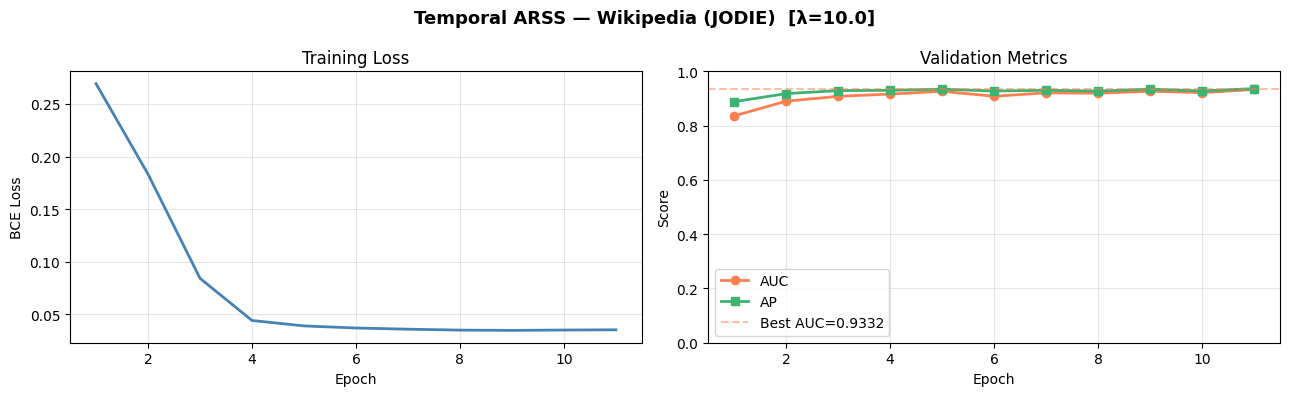

Best validation AUC: 0.9332  (λ=10.0)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(best_train_losses) + 1)

axes[0].plot(ep, best_train_losses, color='steelblue', linewidth=2)
axes[0].set(title='Training Loss', xlabel='Epoch', ylabel='BCE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(best_val_epochs_plot, best_val_aucs_plot, 'o-', label='AUC',
             color='coral', linewidth=2)
axes[1].plot(best_val_epochs_plot, best_val_aps_plot, 's-', label='AP',
             color='mediumseagreen', linewidth=2)
axes[1].axhline(y=overall_best_auc, color='coral', linestyle='--', alpha=0.5,
                label=f'Best AUC={overall_best_auc:.4f}')
axes[1].set(title='Validation Metrics', xlabel='Epoch', ylabel='Score', ylim=(0, 1))
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Temporal ARSS — Wikipedia (JODIE)  [λ={best_lam_label}]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('temporal_arss_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best validation AUC: {overall_best_auc:.4f}  (λ={best_lam_label})')

---
## Cell 9 — Final Test Evaluation and Comparison

Load the best checkpoint and evaluate on the test set.
Print a side-by-side comparison with base ARSS for your report.

In [16]:
model = TemporalARSSModel(hidden=128, emb_dim=64, dropout=0.3).to(DEVICE)
model.load_state_dict(torch.load(
    f'./checkpoints/temporal_arss_lam{BEST_LAMBDA}.pt', map_location=DEVICE
))

test_auc, test_ap = evaluate(
    model, test_src, test_dst, test_t_arr, K, N_ITEMS, N_USERS, BEST_LAMBDA
)

print('=' * 52)
print('  Temporal ARSS — Final Test Results')
print(f'  Wikipedia JODIE  |  λ = {BEST_LAMBDA}')
print('  w_ik_temporal = w_ik * exp(+λ·Δt/T_SCALE)')
print('=' * 52)
print(f'  AUC : {test_auc:.4f}')
print(f'  AP  : {test_ap:.4f}')
print('=' * 52)
print('\nPhase II complete. Compare AUC/AP against Base ARSS test results.')


  Temporal ARSS — Final Test Results
  Wikipedia JODIE  |  λ = 10.0
  w_ik_temporal = w_ik * exp(+λ·Δt/T_SCALE)
  AUC : 0.9142
  AP  : 0.9194

Phase II complete. Compare AUC/AP against Base ARSS test results.
